In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

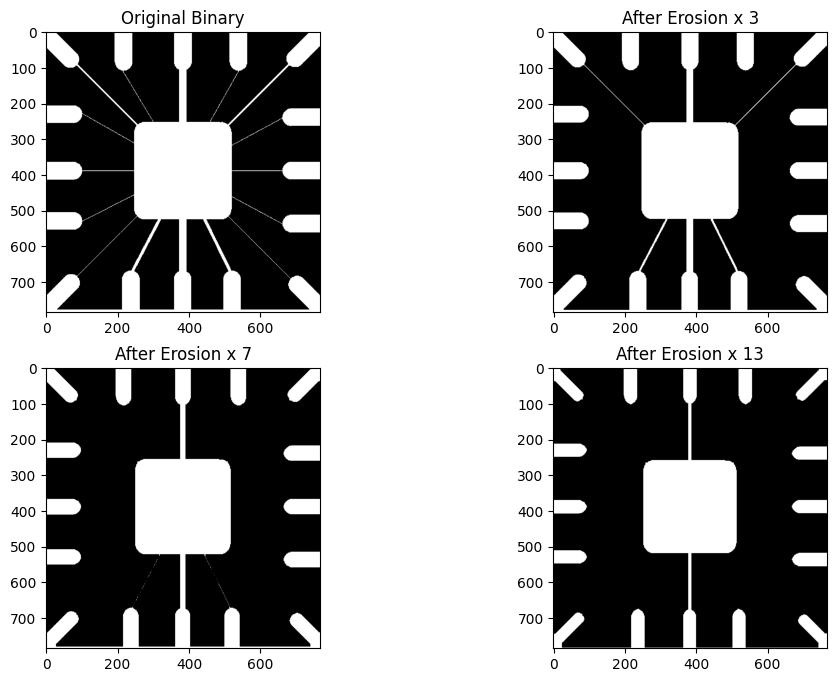

In [14]:
#Erosion

img = cv2.imread("Erosion.jpg",0)

#Make image binary
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#Defining kernels 3x3, 7x7, 13x13

kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel13 = np.ones((13,13), np.uint8)


#Apply Erosion
eroded_img3 = cv2.erode(binary, kernel3, iterations=1)
eroded_img7 = cv2.erode(binary, kernel7, iterations=1)
eroded_img13 = cv2.erode(binary, kernel13, iterations=1)


#Display

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original Binary')
plt.subplot(2, 2, 2), plt.imshow(eroded_img3, 'gray'), plt.title('After Erosion x 3')
plt.subplot(2, 2, 3), plt.imshow(eroded_img7, 'gray'), plt.title('After Erosion x 7')
plt.subplot(2, 2, 4), plt.imshow(eroded_img13, 'gray'), plt.title('After Erosion x 13')


plt.show()


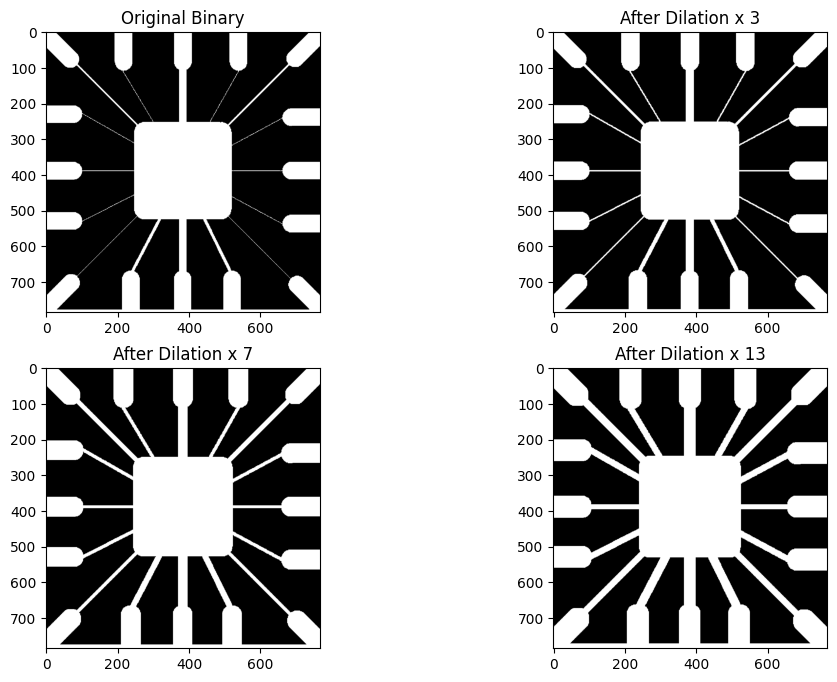

In [24]:
#Dilation

img = cv2.imread("Erosion.jpg",0)

_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)


kernel3 = np.ones((3, 3), np.uint8)
kernel7 = np.ones((7, 7), np.uint8)
kernel13 = np.ones((13, 13), np.uint8)

#Dilation
eroded_img3 = cv2.dilate(binary, kernel3, iterations=1)
eroded_img7 = cv2.dilate(binary, kernel7, iterations=1)
eroded_img13 = cv2.dilate(binary, kernel13, iterations=1)

plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original Binary')
plt.subplot(2, 2, 2), plt.imshow(eroded_img3, 'gray'), plt.title('After Dilation x 3')
plt.subplot(2, 2, 3), plt.imshow(eroded_img7, 'gray'), plt.title('After Dilation x 7')
plt.subplot(2, 2, 4), plt.imshow(eroded_img13, 'gray'), plt.title('After Dilation x 13')

plt.show()



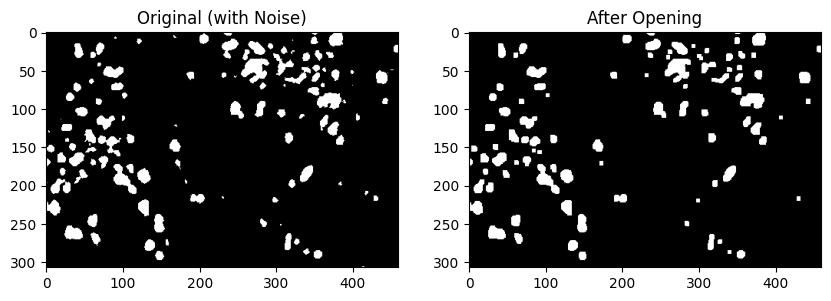

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

#Load image and binarize
img = cv2.imread("Open_Closing.jpg", 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#Define kernel (a 5x5 square is a good starting point)
kernel = np.ones((5, 5), np.uint8)

#Apply Opening
opening = cv2.morphologyEx(binary, cv2.MORPH_OPEN, kernel)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original (with Noise)')
plt.subplot(1, 2, 2), plt.imshow(opening, 'gray'), plt.title('After Opening')
plt.show()


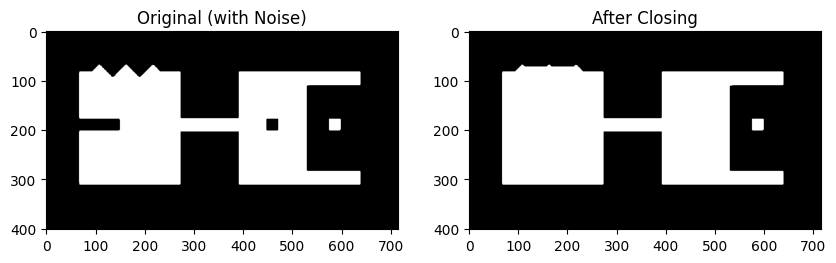

In [31]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


#Load image and binarize
img = cv2.imread("Opening2.jpg", 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#Define kernel (a 45x45 square is a good starting point)
kernel = np.ones((45,45), np.uint8)

#Apply Opening
closing = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(binary, 'gray'), plt.title('Original (with Noise)')
plt.subplot(1, 2, 2), plt.imshow(closing, 'gray'), plt.title('After Closing')
plt.show()

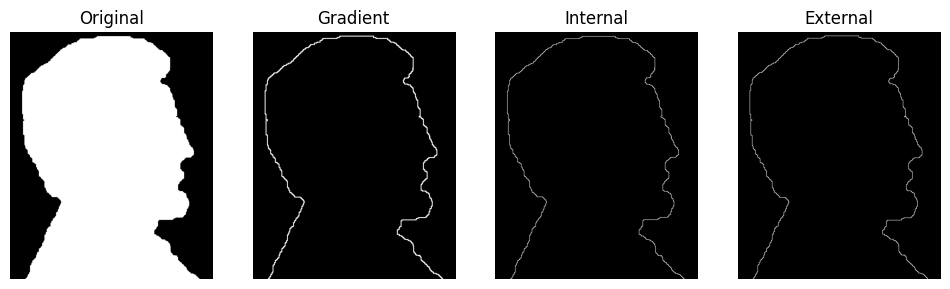

In [33]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


img = cv2.imread("BoundaryExtraction.jpg", 0)
_, binary = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

#Define a kernel
kernel = np.ones((3, 3), np.uint8)

#Method A: Morphological Gradient
gradient = cv2.morphologyEx(binary, cv2.MORPH_GRADIENT, kernel)

#Method B: Internal Boundary
eroded = cv2.erode(binary, kernel)
internal = cv2.subtract(binary, eroded)

#Method C: External Boundary
dilated = cv2.dilate(binary, kernel)
external = cv2.subtract(dilated, binary)


titles = ['Original', 'Gradient', 'Internal', 'External']
images = [binary, gradient, internal, external]

plt.figure(figsize=(12, 4))
for i in range(4):
    plt.subplot(1, 4, i+1)
    plt.imshow(images[i], 'gray')
    plt.title(titles[i])
    plt.axis('off')
plt.show()